# Notebook 12 — Lean Quantile Models: V1 vs V2 Cleaning Comparison

**Objective:** Isolate the effect of the improved outlier removal on model performance.

| | V1 | V2 |
|---|---|---|
| **Data cleaning** | Brand-only IQR (original `clean_car_data`) | Brand+year IQR (`CarDataProcessor` updated) |
| **Features** | Lean: brand/model/year stats only | **Identical** to V1 |
| **Hyperparameters** | `lr=0.1`, `n=5000` | **Identical** to V1 |
| **Feature engineer** | `brand_onehot=False`, `model_onehot=False` | **Identical** to V1 |

**V1** is the pre-trained production model from NB06 (retrained on 100% of October data).  
**V2** is retrained here from scratch on V2-cleaned October data.  
Both are evaluated on the **same held-out test set** (20% of V2-cleaned October data).

**Sections:**
1. Setup & Constants
2. Load October Raw Data
3. V1 — Load Pre-trained Pipeline (NB06 production)
4. V2 — Clean with Brand+Year IQR
5. Shared Evaluation Setup (split, feature engineering, train V2)
6. Compare Metrics on Shared Test Set
7. Median APE by Calendar Year
8. Median APE by Age Bucket
9. Coverage by Year
10. Retrain V2 on Full Data (production)
11. Save V2 Lean Models
12. MLflow Logging
13. Summary

## 1. Setup & Constants

In [2]:
import os
import sys
import json
import importlib
import joblib
from datetime import datetime
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from lightgbm import LGBMRegressor
import mlflow
import mlflow.lightgbm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Project root
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

import data_processing
import features.feature_engineering as _fe_module
importlib.reload(_fe_module)
from features.feature_engineering import CarPriceFeatureEngineer
from data_processing import CarDataProcessor
from config import DATA_PATH

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# ── Constants ────────────────────────────────────────────────────────────────
CURRENT_YEAR    = 2025
TRAIN_TEST_SEED = 42
MLFLOW_URI      = f"file://{project_root / 'mlruns'}"

# ── Paths ─────────────────────────────────────────────────────────────────────
oct_data_dir = Path(os.path.join(DATA_PATH, 'le_boncoin_13_oct_2025'))
v1_dir       = project_root / 'models' / 'lean_quantile'
v2_dir       = project_root / 'models' / 'lean_quantile_v2_lean'
output_dir   = project_root / 'output'

# ── Shared lean feature set (identical to NB06 production model) ──────────────
# 31 features: brand/model/year aggregates only — no km, no fuel type, no HP
LEAN_FEATURES = [
    'car_age',
    'brand_avg_age',       'brand_median_age',
    'brand_mean_log_price','brand_median_log_price','brand_std_log_price',
    'model_count',         'model_popularity_ratio',
    'model_mean_log_price','model_median_log_price','model_std_log_price',
    'is_almost_new',       'decade',
    'sqrt_age',            'age_squared',           'age_cubed',
    'brand_top25_price',   'brand_bottom25_price',  'brand_top5_price',
    'model_top25_price',   'model_bottom25_price',  'model_top5_price',
    'model_rank_within_brand',
    'brand_p25_log_price', 'brand_p75_log_price',   'brand_p90_log_price', 'brand_iqr_log_price',
    'model_p25_log_price', 'model_p75_log_price',   'model_p90_log_price', 'model_iqr_log_price',
]

# ── LightGBM hyperparameters (identical to NB06) ─────────────────────────────
LGB_PARAMS = dict(
    objective   = 'quantile',
    learning_rate = 0.1,
    n_estimators  = 5000,
    random_state  = TRAIN_TEST_SEED,
    verbose       = -1,
)

print(f'Project root : {project_root}')
print(f'October data : {oct_data_dir}')
print(f'V1 models    : {v1_dir}')
print(f'V2 models    : {v2_dir}')
print(f'MLflow store : {MLFLOW_URI}')
print(f'Lean features: {len(LEAN_FEATURES)}')
print('✓ Setup complete')

Project root : /Users/brunobrumbrum/car_price_prediction
October data : /Users/brunobrumbrum/Documents/data/car_price_prediction/le_boncoin_13_oct_2025
V1 models    : /Users/brunobrumbrum/car_price_prediction/models/lean_quantile
V2 models    : /Users/brunobrumbrum/car_price_prediction/models/lean_quantile_v2_lean
MLflow store : file:///Users/brunobrumbrum/car_price_prediction/mlruns
Lean features: 31
✓ Setup complete


## 2. Load October Raw Data

In [3]:
df_raw = data_processing.load_car_data(oct_data_dir)
print(f'Raw October rows: {len(df_raw):,}')

📊 Parsing horsepower from puissance_din column...
✅ Loaded 732,427 rows with horsepower parsed
   Note: 'energie' column contains fuel type (kept as-is)
(732427, 36)
Raw October rows: 732,427


## 3. V1 — Load Pre-trained Pipeline (NB06 production)

V1 models were trained in NB06 on 100% of October data cleaned with the **original brand-only IQR**.  
We load the saved artifacts directly — no retraining.

In [4]:
# Load V1 feature engineer and models
fe_v1 = joblib.load(v1_dir / 'feature_engineer_lean.pkl')
models_v1 = {
    'q15': joblib.load(v1_dir / 'lgb_q15_lean.pkl'),
    'q50': joblib.load(v1_dir / 'lgb_q50_lean.pkl'),
    'q85': joblib.load(v1_dir / 'lgb_q85_lean.pkl'),
}

with open(v1_dir / 'metadata.json') as f:
    meta_v1 = json.load(f)

# V1 feature list — read from disk to guarantee exact match with saved models
feat_cols_v1 = (v1_dir / 'feature_list.txt').read_text().strip().splitlines()

print(f'V1 training date  : {meta_v1["training_date"]}')
print(f'V1 training samples: {meta_v1["n_samples"]:,}')
print(f'V1 features        : {len(feat_cols_v1)}')
print(f'V1 known brands    : {len(fe_v1.brand_price_stats_)}')
print(f'V1 known models    : {len(fe_v1.model_price_stats_)}')
print(f'\n✓ V1 pipeline loaded')

# Confirm feature list match
mismatch = set(feat_cols_v1) ^ set(LEAN_FEATURES)
if mismatch:
    print(f'⚠️  Feature list mismatch: {mismatch}')
else:
    print(f'✓ V1 feature list matches LEAN_FEATURES exactly ({len(feat_cols_v1)} cols)')

V1 training date  : 2026-03-13
V1 training samples: 620,918
V1 features        : 31
V1 known brands    : 43
V1 known models    : 805

✓ V1 pipeline loaded
✓ V1 feature list matches LEAN_FEATURES exactly (31 cols)


## 4. V2 — Clean with Brand+Year IQR

Same October raw data, cleaned with the **updated** `CarDataProcessor` that groups IQR by `(brand, year)`.  
Old cars are now compared against other old cars of the same brand instead of all cars of that brand.

In [5]:
proc_v2 = CarDataProcessor(
    large_group_threshold=50,
    min_group_size=10,
    verbose=True,
)
df_v2 = proc_v2.clean_data(df_raw)
df_v2 = df_v2.with_columns(pl.col('price').log().alias('log_price'))

stats = proc_v2.cleaning_stats.get('outlier_removal', {})
print(f'\n━━━ V2 cleaning summary (brand+year IQR) ━━━')
print(f"  Rows before IQR   : {stats.get('rows_before', '?'):,}")
print(f"  Removed by IQR    : {stats.get('n_dropped_iqr', '?'):,}")
print(f"  Removed (tiny gr.): {stats.get('n_dropped_small_groups', '?'):,}")
print(f"  Rows after        : {stats.get('rows_after', '?'):,}")
print(f'\nV2 final dataset : {len(df_v2):,} rows')
print(f'Year range       : {df_v2["year"].min()} – {df_v2["year"].max()}')
print(f'Unique brands    : {df_v2["brand"].n_unique()}')
print(f'Unique models    : {df_v2["model"].n_unique()}')

🧹 Starting data cleaning pipeline...

1️⃣ Converting data types and normalizing text...
   Original: 732,427 rows
   After conversion: 732,426 rows
   Removed (invalid price): 1
   Unique brands: 145, Unique models: 1646

2️⃣ Removing antique cars (pre-1990)...
   Removed 14,536 antique cars

3️⃣ Removing 'autre' entries...
   Removed 4,347 'autre' entries

4️⃣ Cleaning horsepower...
   HP cleaning: dropped 5620 cars <50HP, 114 cars >1000HP, 35437 outliers (IQR per brand), 0 missing HP
   Remaining dataset - Mean HP: 139.7, Median HP: 125.0

5️⃣ Dropping rare brands (<400 cars)...
   Dropped 3,805 cars from 65 rare brands (< 400 observations)
   Remaining: 43 brands

6️⃣ Removing price/km outliers (brand+year IQR 1.5×; large_group≥50; min_pool=10)...
   brand='kia'                 year=2001  pool_size=7  → DROPPED (below min_group_size=10)
   brand='chrysler'            year=1990  pool_size=7  → DROPPED (below min_group_size=10)
   brand='subaru'              year=1993  pool_size=5  → 

## 5. Shared Evaluation Setup

We split the **V2-cleaned** data 80/20 with the same seed as NB06.  
The 20% test set is used to evaluate **both** V1 and V2 on exactly the same cars.

In [6]:
# ── 5a. Train / Test Split ─────────────────────────────────────────────────────
train_idx, test_idx = train_test_split(
    range(len(df_v2)), test_size=0.2, random_state=TRAIN_TEST_SEED
)
df_train_v2 = df_v2[train_idx]
df_test_v2  = df_v2[test_idx]

# Ground-truth arrays for evaluation
y_test_eur  = df_test_v2['price'].to_numpy()
years_test  = df_test_v2['year'].to_numpy()
age_test    = CURRENT_YEAR - years_test

print(f'V2 train : {len(df_train_v2):,}  |  V2 test : {len(df_test_v2):,}')
print(f'Test year range: {years_test.min()} – {years_test.max()}')
print(f'Test price range: €{y_test_eur.min():,.0f} – €{y_test_eur.max():,.0f}')

V2 train : 490,515  |  V2 test : 122,629
Test year range: 1990 – 2025
Test price range: €250 – €629,990


In [7]:
# ── 5b. Feature Engineering — V2, Lean Spec ───────────────────────────────────
# Identical config to NB06: no OHE, no km/fuel/hp features in model output
fe_v2 = CarPriceFeatureEngineer(
    current_year=CURRENT_YEAR,
    brand_onehot=False,
    model_onehot=False,
)

# Fit on training data ONLY (no leakage) — pass raw price as y
fe_v2.fit(
    df_train_v2.drop(['price', 'log_price']),
    df_train_v2['price'],
)

# Transform both sets
df_train_fe_v2 = fe_v2.transform(df_train_v2.drop(['price', 'log_price']))
df_test_fe_v2  = fe_v2.transform(df_test_v2.drop(['price', 'log_price']))

# Select lean features — same 31 columns as V1
# Any missing columns default to 0 (robust against minor FE version differences)
def select_lean(df_fe, feat_cols):
    X = df_fe.to_pandas().fillna(0)
    for c in feat_cols:
        if c not in X.columns:
            print(f'  ⚠️  Missing: {c} — filling with 0')
            X[c] = 0
    return X[feat_cols].copy()

X_train_v2 = select_lean(df_train_fe_v2, LEAN_FEATURES)
X_test_v2  = select_lean(df_test_fe_v2,  LEAN_FEATURES)

y_train_log_v2 = df_train_v2['log_price'].to_numpy()
y_test_log_v2  = df_test_v2['log_price'].to_numpy()

print(f'X_train_v2: {X_train_v2.shape}  |  X_test_v2: {X_test_v2.shape}')
print(f'V2 known brands: {len(fe_v2.brand_price_stats_)}  |  V2 known models: {len(fe_v2.model_price_stats_)}')
print(f'\n✓ V2 feature engineering complete')

X_train_v2: (490515, 31)  |  X_test_v2: (122629, 31)
V2 known brands: 43  |  V2 known models: 784

✓ V2 feature engineering complete


In [8]:
# ── 5c. Train V2 Quantile Models (same hyperparameters as NB06) ────────────────
models_v2_eval = {}   # trained on 80% — for evaluation only
preds_v2_log   = {}
preds_v2_eur   = {}

for alpha, label in [(0.15, 'q15'), (0.50, 'q50'), (0.85, 'q85')]:
    print(f'Training V2 {label} (alpha={alpha})…', end=' ', flush=True)
    m = LGBMRegressor(alpha=alpha, **LGB_PARAMS)
    m.fit(X_train_v2, y_train_log_v2)
    preds_v2_log[label] = m.predict(X_test_v2)
    preds_v2_eur[label] = np.exp(preds_v2_log[label])
    models_v2_eval[label] = m
    print('done ✓')

mae_v2 = mean_absolute_error(y_test_eur, preds_v2_eur['q50'])
cov_v2 = np.mean((preds_v2_eur['q15'] <= y_test_eur) & (y_test_eur <= preds_v2_eur['q85'])) * 100
print(f'\nV2 q50 MAE       : €{mae_v2:,.0f}')
print(f'V2 Q15-Q85 coverage: {cov_v2:.1f}%  (target ~70%)')

Training V2 q15 (alpha=0.15)… done ✓
Training V2 q50 (alpha=0.5)… done ✓
Training V2 q85 (alpha=0.85)… done ✓

V2 q50 MAE       : €2,428
V2 Q15-Q85 coverage: 69.6%  (target ~70%)


## 6. Compare Metrics on Shared Test Set

V1 predicts the same test cars using its own feature engineer (fit on V1's training data).  
V2 predicts using its own feature engineer (fit on V2's training data).  
Ground truth is identical for both.

In [9]:
# ── V1 predictions on test_v2 ─────────────────────────────────────────────────
# V1's FE was fit on V1's training data — transform test_v2 with those encodings
df_test_fe_v1 = fe_v1.transform(df_test_v2.drop(['price', 'log_price']))
X_test_v1 = select_lean(df_test_fe_v1, feat_cols_v1)

preds_v1_log = {}
preds_v1_eur = {}
for label, m in models_v1.items():
    preds_v1_log[label] = m.predict(X_test_v1)
    preds_v1_eur[label] = np.exp(preds_v1_log[label])

mae_v1 = mean_absolute_error(y_test_eur, preds_v1_eur['q50'])
cov_v1 = np.mean((preds_v1_eur['q15'] <= y_test_eur) & (y_test_eur <= preds_v1_eur['q85'])) * 100
print(f'V1 q50 MAE       : €{mae_v1:,.0f}')
print(f'V1 Q15-Q85 coverage: {cov_v1:.1f}%')
print(f'\n✓ V1 predictions on shared test set complete')

V1 q50 MAE       : €2,419
V1 Q15-Q85 coverage: 70.0%

✓ V1 predictions on shared test set complete


In [10]:
# ── Side-by-side metrics table ────────────────────────────────────────────────
def pinball_loss(y_true, y_pred, alpha):
    errors = y_true - y_pred
    return float(np.mean(np.where(errors >= 0, alpha * errors, (alpha - 1) * errors)))

def full_metrics(y_true, preds_log, preds_eur, variant):
    act, p15, p50, p85 = y_true, preds_eur['q15'], preds_eur['q50'], preds_eur['q85']
    n = len(act)
    rows = []
    for alpha, label in [(0.15, 'q15'), (0.50, 'q50'), (0.85, 'q85')]:
        pred_eur = preds_eur[label]
        r2 = r2_score(act, pred_eur)
        rows.append({
            'Variant':      variant,
            'Model':        label.upper(),
            'MAE (€)':      round(mean_absolute_error(act, pred_eur)),
            'RMSE (€)':     round(np.sqrt(mean_squared_error(act, pred_eur))),
            'Median APE (%)': round(float(np.median(np.abs(act - pred_eur) / np.clip(act, 1, None) * 100)), 2),
            'Pinball':       round(pinball_loss(np.log(np.clip(act, 1e-6, None)), preds_log[label], alpha), 5),
            'R²':           round(r2, 4),
        })
    cov = round(np.mean((p15 <= act) & (act <= p85)) * 100, 1)
    rows[1]['Coverage Q15-Q85'] = f'{cov}%'
    return rows

rows_v1 = full_metrics(y_test_eur, preds_v1_log, preds_v1_eur, 'V1 (brand IQR)')
rows_v2 = full_metrics(y_test_eur, preds_v2_log, preds_v2_eur, 'V2 (brand+year IQR)')

metrics_df = pd.DataFrame(rows_v1 + rows_v2).fillna('')

print('\n' + '='*80)
print('EVALUATION METRICS — V1 vs V2  |  Shared test set (20% of V2-cleaned October data)')
print('='*80)
print(metrics_df.to_string(index=False))
print()
print(f'Test set size: {len(y_test_eur):,} cars')
print('Note: V1 trained on 100% of V1-cleaned data. V2 trained on 80% of V2-cleaned data (eval split).')
display(metrics_df)


EVALUATION METRICS — V1 vs V2  |  Shared test set (20% of V2-cleaned October data)
            Variant Model  MAE (€)  RMSE (€)  Median APE (%)  Pinball     R² Coverage Q15-Q85
     V1 (brand IQR)   Q15     3481      6133           19.62  0.06137 0.8770                 
     V1 (brand IQR)   Q50     2419      4469           12.64  0.09646 0.9347            70.0%
     V1 (brand IQR)   Q85     3839      6146           22.23  0.05449 0.8765                 
V2 (brand+year IQR)   Q15     3462      6193           19.37  0.05870 0.8746                 
V2 (brand+year IQR)   Q50     2428      4506           12.79  0.09598 0.9336            69.6%
V2 (brand+year IQR)   Q85     3778      6045           22.00  0.05485 0.8805                 

Test set size: 122,629 cars
Note: V1 trained on 100% of V1-cleaned data. V2 trained on 80% of V2-cleaned data (eval split).


,Variant,Model,MAE (€),RMSE (€),Median APE (%),Pinball,R²,Coverage Q15-Q85
0,V1 (brand IQR),Q15,3481,6133,19.62,0.06137,0.8770,
1,V1 (brand IQR),Q50,2419,4469,12.64,0.09646,0.9347,70.0%
2,V1 (brand IQR),Q85,3839,6146,22.23,0.05449,0.8765,
3,V2 (brand+year IQR),Q15,3462,6193,19.37,0.05870,0.8746,
4,V2 (brand+year IQR),Q50,2428,4506,12.79,0.09598,0.9336,69.6%
5,V2 (brand+year IQR),Q85,3778,6045,22.00,0.05485,0.8805,


## 7. Median APE by Calendar Year

Scale-independent metric: per-car `|actual − pred_q50| / actual × 100`, then **median** per year.  
This is the key chart to see whether V2 reduces error on old cars (the known age-bias problem).

In [11]:
AGE_BUCKETS = [
    (0,  2,  '0-2 yr (2023-25)'),
    (3,  5,  '3-5 yr (2020-22)'),
    (6,  10, '6-10 yr (2015-19)'),
    (11, 15, '11-15 yr (2010-14)'),
    (16, 20, '16-20 yr (2005-09)'),
    (21, 99, '21+ yr (pre-2005)'),
]

def age_to_bucket(age):
    for lo, hi, lab in AGE_BUCKETS:
        if lo <= age <= hi:
            return lab
    return 'unknown'

def compute_year_metrics(y_true, y_q50, y_q15, y_q85, years, min_n=5):
    rows = []
    for yr in sorted(np.unique(years)):
        mask = years == yr
        if mask.sum() < min_n:
            continue
        act, pred, lo, hi = y_true[mask], y_q50[mask], y_q15[mask], y_q85[mask]
        rows.append({
            'year':          yr,
            'n':             int(mask.sum()),
            'median_ape':    round(float(np.median(np.abs(act - pred) / np.clip(act, 1, None) * 100)), 2),
            'coverage_70':   round(float(np.mean((lo <= act) & (act <= hi))), 4),
            'median_signed': round(float(np.median((pred - act) / np.clip(act, 1, None) * 100)), 2),
        })
    return pd.DataFrame(rows)

ym_v1 = compute_year_metrics(y_test_eur, preds_v1_eur['q50'], preds_v1_eur['q15'], preds_v1_eur['q85'], years_test)
ym_v2 = compute_year_metrics(y_test_eur, preds_v2_eur['q50'], preds_v2_eur['q15'], preds_v2_eur['q85'], years_test)

print('=== V1 Median APE by year (first 8 rows) ===')
print(ym_v1.head(8).to_string(index=False))
print('\n=== V2 Median APE by year (first 8 rows) ===')
print(ym_v2.head(8).to_string(index=False))

=== V1 Median APE by year (first 8 rows) ===
 year   n  median_ape  coverage_70  median_signed
 1990 109       32.28       0.6972           2.65
 1991 144       44.98       0.6389           6.41
 1992 126       42.07       0.6190           5.30
 1993 128       37.61       0.6953          12.14
 1994 135       46.99       0.6222           9.10
 1995 176       42.75       0.6080           9.99
 1996 265       34.77       0.6189          12.20
 1997 265       34.43       0.5736          11.99

=== V2 Median APE by year (first 8 rows) ===
 year   n  median_ape  coverage_70  median_signed
 1990 109       30.53       0.6147           3.17
 1991 144       45.43       0.6806           6.80
 1992 126       42.77       0.6349          -7.68
 1993 128       38.05       0.6484           9.93
 1994 135       46.97       0.5926           6.28
 1995 176       41.51       0.6591           0.57
 1996 265       33.95       0.6981          -0.72
 1997 265       34.90       0.6604          -3.22


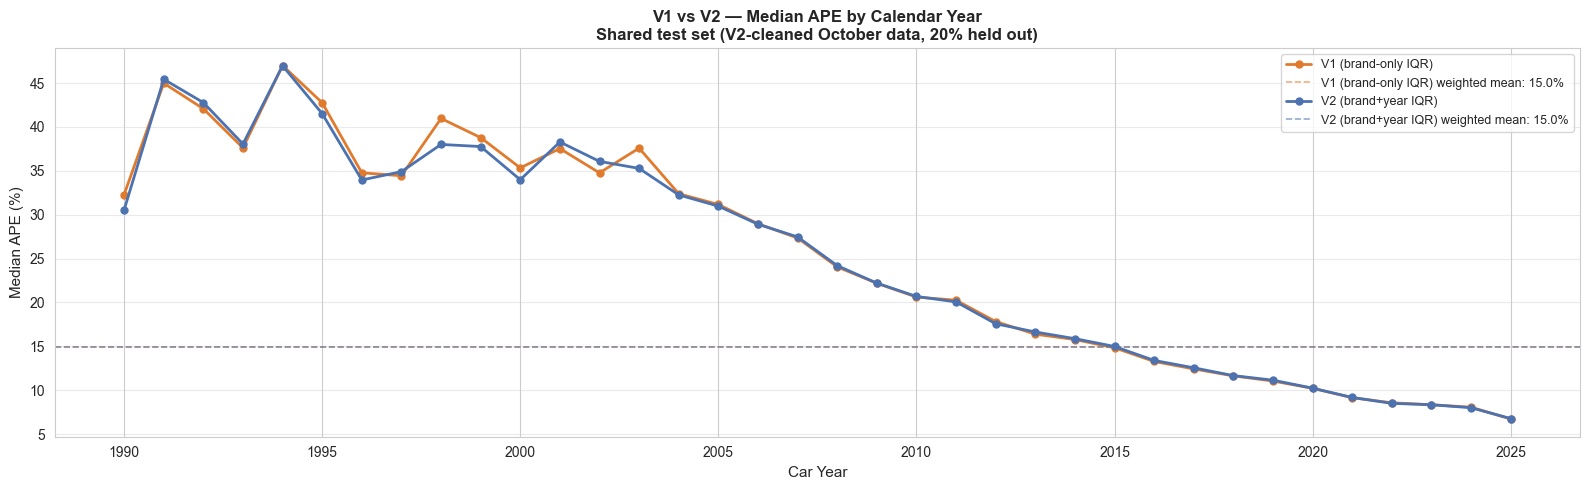

In [12]:
fig, ax = plt.subplots(figsize=(16, 5))

for ym, color, label in [
    (ym_v1, '#E07B2E', 'V1 (brand-only IQR)'),
    (ym_v2, '#4C72B0', 'V2 (brand+year IQR)'),
]:
    ax.plot(ym['year'], ym['median_ape'], marker='o', linewidth=2, color=color,
            markersize=5, label=label)
    wm = (ym['median_ape'] * ym['n']).sum() / ym['n'].sum()
    ax.axhline(wm, color=color, linestyle='--', linewidth=1.2, alpha=0.6,
               label=f'{label} weighted mean: {wm:.1f}%')

ax.set_xlabel('Car Year', fontsize=11)
ax.set_ylabel('Median APE (%)', fontsize=11)
ax.set_title('V1 vs V2 — Median APE by Calendar Year\n'
             'Shared test set (V2-cleaned October data, 20% held out)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Median APE by Age Bucket

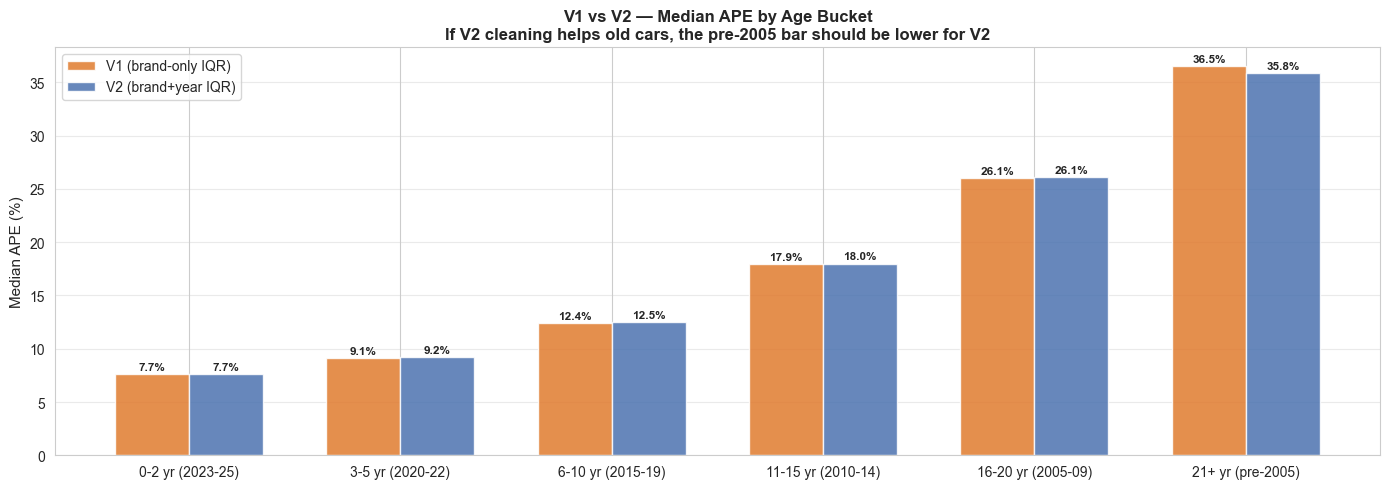


=== Bucket metrics: V1 ===
            bucket     n  median_ape  coverage_70
  0-2 yr (2023-25) 21577        7.66       0.7094
  3-5 yr (2020-22) 25812        9.14       0.7225
 6-10 yr (2015-19) 32394       12.38       0.7132
11-15 yr (2010-14) 21366       17.94       0.7086
16-20 yr (2005-09) 13786       26.06       0.6660
 21+ yr (pre-2005)  7694       36.50       0.5872

=== Bucket metrics: V2 ===
            bucket     n  median_ape  coverage_70
  0-2 yr (2023-25) 21577        7.66       0.6949
  3-5 yr (2020-22) 25812        9.19       0.7041
 6-10 yr (2015-19) 32394       12.53       0.6979
11-15 yr (2010-14) 21366       18.00       0.6946
16-20 yr (2005-09) 13786       26.13       0.6913
 21+ yr (pre-2005)  7694       35.84       0.6829


In [13]:
def compute_bucket_metrics(y_true, y_q50, y_q15, y_q85, years, current_year=CURRENT_YEAR):
    ages = current_year - years
    buckets = np.array([age_to_bucket(a) for a in ages])
    rows = []
    for lo, hi, lab in AGE_BUCKETS:
        mask = buckets == lab
        if mask.sum() < 5:
            continue
        act, pred, lo_p, hi_p = y_true[mask], y_q50[mask], y_q15[mask], y_q85[mask]
        rows.append({
            'bucket':      lab,
            'n':           int(mask.sum()),
            'median_ape':  round(float(np.median(np.abs(act - pred) / np.clip(act, 1, None) * 100)), 2),
            'coverage_70': round(float(np.mean((lo_p <= act) & (act <= hi_p))), 4),
        })
    return pd.DataFrame(rows)

bm_v1 = compute_bucket_metrics(y_test_eur, preds_v1_eur['q50'], preds_v1_eur['q15'], preds_v1_eur['q85'], years_test)
bm_v2 = compute_bucket_metrics(y_test_eur, preds_v2_eur['q50'], preds_v2_eur['q15'], preds_v2_eur['q85'], years_test)

# Align to canonical bucket order
all_buckets = [lab for _, _, lab in AGE_BUCKETS]
bm_v1 = bm_v1.set_index('bucket').reindex(all_buckets).reset_index().rename(columns={'index': 'bucket'})
bm_v2 = bm_v2.set_index('bucket').reindex(all_buckets).reset_index().rename(columns={'index': 'bucket'})

x = np.arange(len(all_buckets))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_v1 = ax.bar(x - width/2, bm_v1['median_ape'].fillna(0), width,
                  label='V1 (brand-only IQR)', color='#E07B2E', alpha=0.85)
bars_v2 = ax.bar(x + width/2, bm_v2['median_ape'].fillna(0), width,
                  label='V2 (brand+year IQR)', color='#4C72B0', alpha=0.85)

for bars, bm in [(bars_v1, bm_v1), (bars_v2, bm_v2)]:
    for bar, val in zip(bars, bm['median_ape'].fillna(0)):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(all_buckets, fontsize=10)
ax.set_ylabel('Median APE (%)', fontsize=11)
ax.set_title('V1 vs V2 — Median APE by Age Bucket\n'
             'If V2 cleaning helps old cars, the pre-2005 bar should be lower for V2',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print('\n=== Bucket metrics: V1 ===')
print(bm_v1[['bucket', 'n', 'median_ape', 'coverage_70']].to_string(index=False))
print('\n=== Bucket metrics: V2 ===')
print(bm_v2[['bucket', 'n', 'median_ape', 'coverage_70']].to_string(index=False))

## 9. Coverage by Year

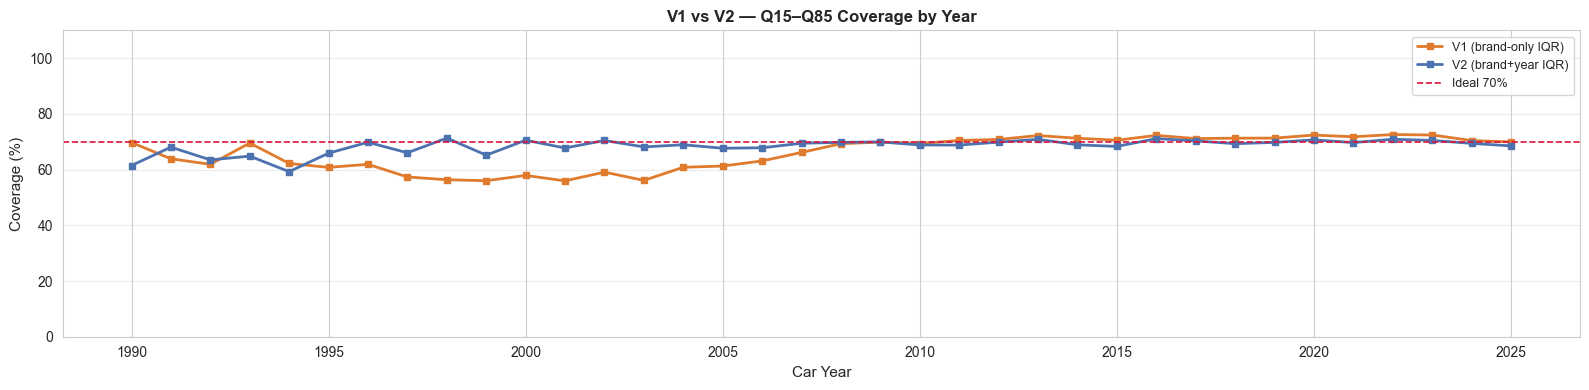

In [14]:
fig, ax = plt.subplots(figsize=(16, 4))

for ym, color, label in [
    (ym_v1, '#E07B2E', 'V1 (brand-only IQR)'),
    (ym_v2, '#4C72B0', 'V2 (brand+year IQR)'),
]:
    ax.plot(ym['year'], ym['coverage_70'] * 100, marker='s', linewidth=2,
            color=color, markersize=5, label=label)

ax.axhline(70, color='crimson', linestyle='--', linewidth=1.2, label='Ideal 70%')
ax.set_ylim(0, 110)
ax.set_xlabel('Car Year', fontsize=11)
ax.set_ylabel('Coverage (%)', fontsize=11)
ax.set_title('V1 vs V2 — Q15–Q85 Coverage by Year', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Retrain V2 on Full Data (Production)

Validation metrics above used the 80% split. Now retrain on 100% of V2-cleaned data  
— same pattern as NB06 Section 9. This is the production model.

In [15]:
print('Fitting production feature engineer on 100% of V2-cleaned data…')

fe_v2_prod = CarPriceFeatureEngineer(
    current_year=CURRENT_YEAR,
    brand_onehot=False,
    model_onehot=False,
)
fe_v2_prod.fit(
    df_v2.drop(['price', 'log_price']),
    df_v2['price'],
)

df_all_fe = fe_v2_prod.transform(df_v2.drop(['price', 'log_price']))
X_all = select_lean(df_all_fe, LEAN_FEATURES)
y_all_log = df_v2['log_price'].to_numpy()

print(f'✓ Production FE fitted on {len(y_all_log):,} samples')
print(f'  Features: {X_all.shape[1]}')
print(f'  Known brands: {len(fe_v2_prod.brand_price_stats_)}')
print(f'  Known models: {len(fe_v2_prod.model_price_stats_)}')

Fitting production feature engineer on 100% of V2-cleaned data…
✓ Production FE fitted on 613,144 samples
  Features: 31
  Known brands: 43
  Known models: 801


In [16]:
models_v2_prod = {}

for alpha, label in [(0.15, 'q15'), (0.50, 'q50'), (0.85, 'q85')]:
    print(f'Training V2 production {label}…', end=' ', flush=True)
    m = LGBMRegressor(alpha=alpha, **LGB_PARAMS)
    m.fit(X_all, y_all_log)
    models_v2_prod[label] = m
    print('done ✓')

print('\n✓ V2 production models trained on 100% of V2-cleaned data')

Training V2 production q15… done ✓
Training V2 production q50… done ✓
Training V2 production q85… done ✓

✓ V2 production models trained on 100% of V2-cleaned data


## 11. Save V2 Lean Models

In [17]:
v2_dir.mkdir(parents=True, exist_ok=True)

for label, m in models_v2_prod.items():
    path = v2_dir / f'lgb_{label}_lean.pkl'
    joblib.dump(m, path)
    print(f'  Saved {path.name}')

joblib.dump(fe_v2_prod, v2_dir / 'feature_engineer_lean.pkl')
print('  Saved feature_engineer_lean.pkl')

(v2_dir / 'feature_list.txt').write_text('\n'.join(LEAN_FEATURES))
print('  Saved feature_list.txt')

(v2_dir / 'brand_list.txt').write_text('\n'.join(sorted(fe_v2_prod.brand_price_stats_.keys())))
print('  Saved brand_list.txt')

metadata_v2 = {
    'training_date':    datetime.now().isoformat(),
    'variant':          'lean_v2_brand_year_iqr_lean_features',
    'n_samples':        len(y_all_log),
    'n_features':       len(LEAN_FEATURES),
    'cleaning': {
        'method':               'brand+year IQR',
        'large_group_threshold': 50,
        'min_group_size':        10,
    },
    'lgb_params':       LGB_PARAMS,
    'validation_mae_q50':  float(mae_v2),
    'validation_coverage': float(cov_v2),
    'features': {
        'all_features': LEAN_FEATURES,
        'total_brands': len(fe_v2_prod.brand_price_stats_),
        'total_models': len(fe_v2_prod.model_price_stats_),
    },
    'comparison_note': 'Identical features and hyperparams to V1. Only cleaning differs.',
}

with open(v2_dir / 'metadata.json', 'w') as f:
    json.dump(metadata_v2, f, indent=2)
print('  Saved metadata.json')

print(f'\n✓ All V2 artifacts saved to {v2_dir}')

  Saved lgb_q15_lean.pkl
  Saved lgb_q50_lean.pkl
  Saved lgb_q85_lean.pkl
  Saved feature_engineer_lean.pkl
  Saved feature_list.txt
  Saved brand_list.txt
  Saved metadata.json

✓ All V2 artifacts saved to /Users/brunobrumbrum/car_price_prediction/models/lean_quantile_v2_lean


## 12. MLflow Logging

In [18]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('car_price_lean_cleaning_comparison')

for variant_label, preds_log, preds_eur_dict, n_train in [
    ('v1_brand_iqr',      preds_v1_log, preds_v1_eur, meta_v1['n_samples']),
    ('v2_brand_year_iqr', preds_v2_log, preds_v2_eur, len(df_train_v2)),
]:
    with mlflow.start_run(run_name=variant_label):
        mlflow.log_params({
            'variant':          variant_label,
            'n_train':          n_train,
            'n_test':           len(y_test_eur),
            'n_features':       len(LEAN_FEATURES),
            'lgb_lr':           LGB_PARAMS['learning_rate'],
            'lgb_n_estimators': LGB_PARAMS['n_estimators'],
        })
        for alpha, label in [(0.15, 'q15'), (0.50, 'q50'), (0.85, 'q85')]:
            pl_val = pinball_loss(np.log(np.clip(y_test_eur, 1e-6, None)), preds_log[label], alpha)
            mlflow.log_metric(f'pinball_{label}', round(pl_val, 5))
            medape = float(np.median(np.abs(y_test_eur - preds_eur_dict[label]) / np.clip(y_test_eur, 1, None) * 100))
            mlflow.log_metric(f'median_ape_{label}', round(medape, 3))
        cov = float(np.mean((preds_eur_dict['q15'] <= y_test_eur) & (y_test_eur <= preds_eur_dict['q85'])))
        mlflow.log_metric('coverage_q15_q85', round(cov, 4))
        mlflow.log_metric('mae_q50_eur', round(mean_absolute_error(y_test_eur, preds_eur_dict['q50']), 2))
        print(f'  ✓ Logged {variant_label}')

print(f'\nMLflow experiment : car_price_lean_cleaning_comparison')
print(f'Location          : {MLFLOW_URI}')
print(f'(View with: mlflow ui --backend-store-uri {MLFLOW_URI} --port 5001)')

2026/05/12 18:07:55 INFO mlflow.tracking.fluent: Experiment with name 'car_price_lean_cleaning_comparison' does not exist. Creating a new experiment.


  ✓ Logged v1_brand_iqr
  ✓ Logged v2_brand_year_iqr

MLflow experiment : car_price_lean_cleaning_comparison
Location          : file:///Users/brunobrumbrum/car_price_prediction/mlruns
(View with: mlflow ui --backend-store-uri file:///Users/brunobrumbrum/car_price_prediction/mlruns --port 5001)


## 13. Summary

In [19]:
wm_v1 = (ym_v1['median_ape'] * ym_v1['n']).sum() / ym_v1['n'].sum()
wm_v2 = (ym_v2['median_ape'] * ym_v2['n']).sum() / ym_v2['n'].sum()

delta_mae   = mae_v2 - mae_v1
delta_medape = wm_v2 - wm_v1
delta_cov   = cov_v2 - cov_v1

print('=' * 65)
print('SUMMARY — V1 vs V2 Cleaning Comparison')
print('=' * 65)
print(f'Test set : {len(y_test_eur):,} cars (same for both models)')
print()
print(f'                       V1            V2        Delta')
print(f'  MAE q50 (€)       : {mae_v1:>9,.0f}    {mae_v2:>9,.0f}    {delta_mae:>+9,.0f}')
print(f'  Median APE wm (%) : {wm_v1:>9.2f}    {wm_v2:>9.2f}    {delta_medape:>+9.2f}')
print(f'  Q15-Q85 coverage  : {cov_v1:>9.1f}%   {cov_v2:>9.1f}%   {delta_cov:>+8.1f}pp')
print()
print('Features   : lean spec (31 cols — brand/model/year stats only)')
print('Hyperparams: lr=0.1, n=5000 (identical for both)')
print('V1 trained : NB06, 100% of V1-cleaned October data')
print('V2 trained : 80% of V2-cleaned October data (eval split)')
print('V2 prod    : retrained on 100% of V2-cleaned October data')
print(f'V2 saved to: {v2_dir}')
print()
print('Interpretation guide:')
print('  MAE / Median APE lower  → better overall accuracy')
print('  Pre-2005 bucket lower   → age bias reduced by new cleaning')
print('  Coverage closer to 70%  → better calibrated intervals')
print('\n✓ Notebook complete')

SUMMARY — V1 vs V2 Cleaning Comparison
Test set : 122,629 cars (same for both models)

                       V1            V2        Delta
  MAE q50 (€)       :     2,419        2,428           +9
  Median APE wm (%) :     14.97        14.97        -0.00
  Q15-Q85 coverage  :      70.0%        69.6%       -0.4pp

Features   : lean spec (31 cols — brand/model/year stats only)
Hyperparams: lr=0.1, n=5000 (identical for both)
V1 trained : NB06, 100% of V1-cleaned October data
V2 trained : 80% of V2-cleaned October data (eval split)
V2 prod    : retrained on 100% of V2-cleaned October data
V2 saved to: /Users/brunobrumbrum/car_price_prediction/models/lean_quantile_v2_lean

Interpretation guide:
  MAE / Median APE lower  → better overall accuracy
  Pre-2005 bucket lower   → age bias reduced by new cleaning
  Coverage closer to 70%  → better calibrated intervals

✓ Notebook complete
